In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv("../test_out/sort_results_18.tsv", sep="\t")

categories = {
    'CVA16': [],
    'non_EV_A': [],
    'EV_A': [],
    'fragments': [],
    'inter_recombinants': [],
    'intra_recombinants': []
}


for name in df.seqName:
    # Determine category based on sequence ID (check in order of specificity)
    if name.startswith('inter_'):  # Inter-recombinants first
        categories['inter_recombinants'].append(name)
    elif name.startswith('intra_'):  # Intra-recombinants
        categories['intra_recombinants'].append(name)
    elif '_partial_' in name:  # Fragments
        categories['fragments'].append(name)
    elif 'EV-A' in name or 'CVA' in name:  # EV-A sequences (but not CVA16)
        if 'CVA16' not in name:
            categories['EV_A'].append(name)
    elif '|' in name:  # Non-CVA16 (has pipe symbol)
        categories['non_EV_A'].append(name)
    else:  # CVA16
        categories['CVA16'].append(name)


df["category"] = df["seqName"].apply(lambda x: "CVA16" if x in categories['CVA16'] else
                                              "non_EV_A" if x in categories['non_EV_A'] else
                                              "EV_A" if x in categories['EV_A'] else
                                              "fragments" if x in categories['fragments'] else
                                              "inter_recombinants" if x in categories['inter_recombinants'] else
                                              "intra_recombinants" if x in categories['intra_recombinants'] else
                                              "CVA16")
# remove non cva16 datasets
df = df[df["dataset"] != "enpen/enterovirus/ev-d68"]
## get number of not empty numHits per category
hit_counts = df[df["numHits"] > 0].groupby("category").size()
# print(f"Number of sequences that succeeded:\n{hit_counts.to_frame(name='Count').to_markdown()}\n")

## get number of failed (nan) numHits per category
failed_counts = df[df["numHits"].isna()].groupby("category").size()
# print(f"Number of sequences that failed:\n{failed_counts.to_frame(name='Count').to_markdown()}\n")

# Create summary dataframe
summary = pd.DataFrame({
    'Succeeded': hit_counts,
    'Failed': failed_counts
}).fillna(0).astype(int)

summary['Total'] = summary['Succeeded'] + summary['Failed']
print(summary.to_markdown())

| category           |   Succeeded |   Failed |   Total |
|:-------------------|------------:|---------:|--------:|
| CVA16              |        8533 |      702 |    9235 |
| EV_A               |           0 |       25 |      25 |
| fragments          |          24 |        6 |      30 |
| inter_recombinants |           4 |        6 |      10 |
| intra_recombinants |          10 |        0 |      10 |
| non_EV_A           |           0 |        5 |       5 |


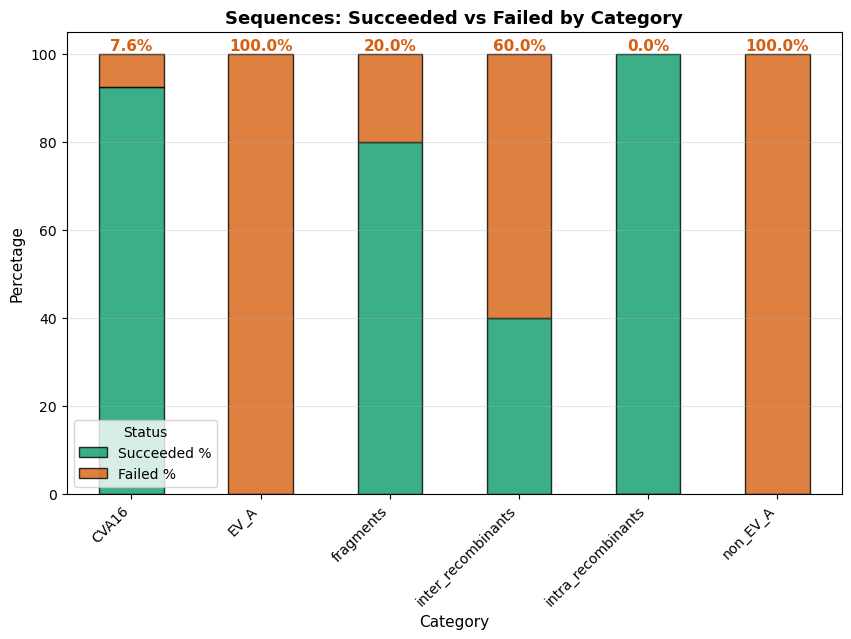

In [79]:
import matplotlib.pyplot as plt

summary['Failed %'] = (summary['Failed'] / summary['Total'] * 100).round(1)
summary['Succeeded %'] = (summary['Succeeded'] / summary['Total'] * 100).round(1)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot 1: Stacked bar chart (Failed vs Succeeded)
summary[['Succeeded %', 'Failed %']].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=["#0b9b6b", "#d66010"],
    edgecolor='black',
    alpha=0.8
)


for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(i, 100, f"{row['Failed %']:.1f}%", 
            ha='center', va='bottom', color="#d66010", fontweight='bold', fontsize=11)
    
ax.set_title('Sequences: Succeeded vs Failed by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Percetage', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Status', fontsize=10)
ax.grid(axis='y', alpha=0.3)


plt.savefig('../test_out/sequences_status_by_category.png', dpi=300, bbox_inches='tight')
plt.show()